In [ ]:
# 강사풀이

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = 'https://raw.githubusercontent.com/pia222sk20/python/refs/heads/main/data/tellecom.csv'
data = pd.read_csv(url)
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.shape

(7043, 21)

In [4]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<Axes: >

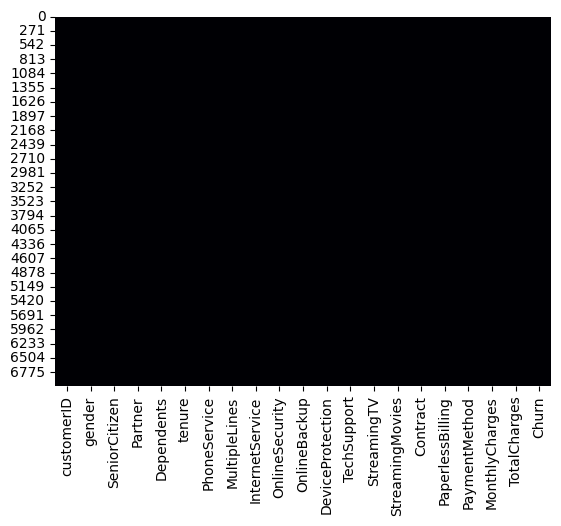

In [6]:
sns.heatmap(data.isnull(), cmap = 'magma', cbar=False)

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75


In [9]:
'''
이 데이터셋에는 텍스트 형태의 데이터가 많은 특성(컬럼) 이 있으며, 이들은 아마도 범주형(feature) 일 가능성이 높습니다.
Total Charges 특성은 숫자형 값을 가지고 있지만, 현재 문자열(string) 형태로 저장되어 있습니다.
따라서, 먼저 이 열을 실수(float) 형으로 변환하겠습니다.
'''

l1 = [len(i.split()) for i in data['TotalCharges']]
l2 = [i for i in range(len(l1)) if l1[i] != 1]
print('Index Positions with empty spaces : ',*l2)

for i in l2:
    data.loc[i,'TotalCharges'] = data.loc[(i-1),'TotalCharges']

data['TotalCharges'] = data['TotalCharges'].astype(float)
data.drop(columns = ['customerID'], inplace = True)

Index Positions with empty spaces :  488 753 936 1082 1340 3331 3826 4380 5218 6670 6754


In [ ]:
# TotalCharges 열을 float(실수형) 으로 변환하는 과정에서
# 문자열을 숫자로 변환할 수 없다는 오류가 발생했습니다.

# 이 오류는 TotalCharges 열에 빈 문자열(공백 문자열, ' ') 이 포함되어 있기 때문입니다.
# 예를 들어, a = ' ' 과 같은 값은 문자열이지만 결측값(null) 으로 인식되지 않기 때문에,
# 결측값 시각화(예: 히트맵)에서는 표시되지 않았던 것입니다.

# 따라서, 우리는 TotalCharges 열의 각 원소를 문자열로 분리(split)하고,
# 그 길이가 1이 아닌(즉, 비어 있는) 요소들의 인덱스 번호를 추출했습니다.
# 이 인덱스 목록에 해당하는 값들은 이전 행의 값으로 대체(fill) 했습니다.

# 그 후 전체 TotalCharges 열을 astype(float)을 사용하여 실수형으로 변환했습니다.

# 마지막으로 고유 식별자 역할만 하는 customerID 열을 삭제하고,
# 데이터셋의 특성을 수치형(numerical) 과 범주형(categorical) 으로 구분했습니다.
# 범주형 특성들에 대해서는 레이블 인코딩(label encoding) 을 수행합니다.